In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv("Real estate.csv")
print("Read successfully")

Read successfully


In [8]:
print(df.columns)
print(df.shape)

Index(['No', 'X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='object')
(414, 8)


In [19]:
X = df.drop("Y house price of unit area", axis=1).values
y = df["Y house price of unit area"].values
print(X.shape, y.shape)

(414, 7) (414,)


In [20]:
X_longitude=X[:,6]


In [21]:
X_longitude=X_longitude.reshape(-1,1)
print(X_longitude.shape)

(414, 1)


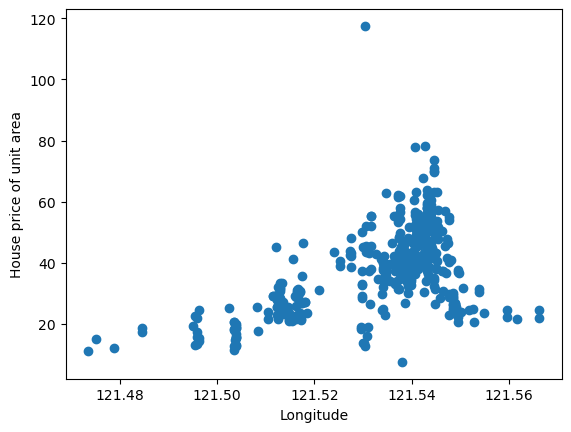

In [22]:
import matplotlib.pyplot as plt 
plt.scatter(X_longitude, y)
plt.xlabel("Longitude")
plt.ylabel("House price of unit area")
plt.show()

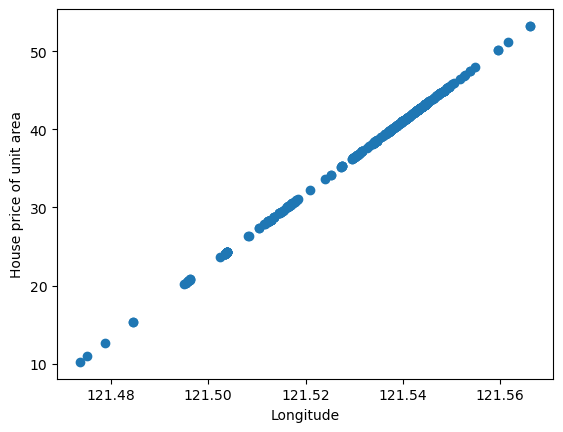

In [24]:
from sklearn.linear_model import LinearRegression
house = LinearRegression()
house.fit(X_longitude, y)
pred=house.predict(X_longitude)
plt.scatter(X_longitude, pred)
plt.xlabel("Longitude")
plt.ylabel("House price of unit area")
plt.show()


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.3, random_state=42)
reg = LinearRegression()
reg.fit(X_train, y_train)
y_pred=reg.predict(X_test)



In [27]:
reg.score(X_test, y_test)

0.5532450005316563

In [30]:
from sklearn.metrics import mean_squared_error
import numpy as np
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:", rmse)


Root Mean Squared Error: 8.643416956340504


In [32]:
from sklearn.model_selection import cross_val_score, KFold
kf=KFold(n_splits=7, shuffle=True, random_state=42)
reg=LinearRegression()
scores= cross_val_score(reg, X, y, cv=kf)
print("Cross-validation scores:", scores)
print("np.mean(scores):", np.mean(scores))
print("np.std(scores):", np.std(scores))

Cross-validation scores: [0.64397624 0.51794394 0.55534696 0.5928527  0.63650361 0.61772083
 0.430162  ]
np.mean(scores): 0.5706437551519156
np.std(scores): 0.07088325082050517
